In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Matrix and Matmul

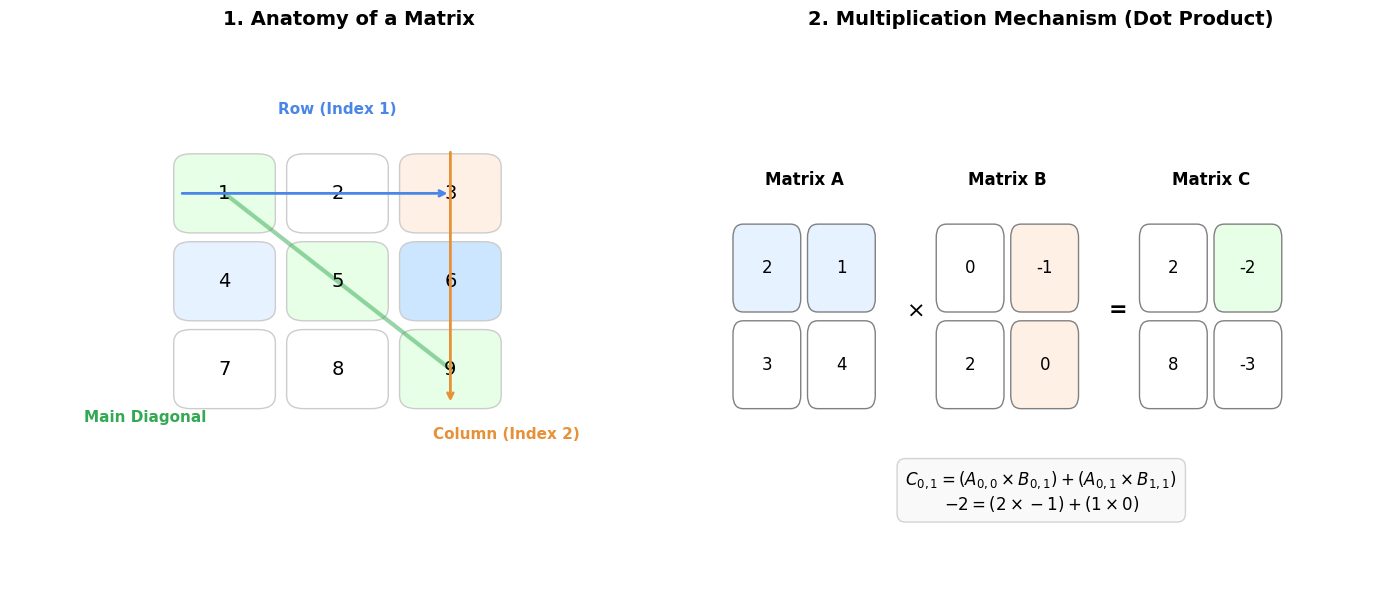

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.set_xlim(0, 6)
ax1.set_ylim(0, 6)
ax1.axis('off')
ax1.set_title("1. Anatomy of a Matrix", fontsize=14, fontweight='bold', pad=20)

matrix_vals = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]

for i in range(3):
    for j in range(3):
        x = 1.5 + j
        y = 4 - i
        
        facecolor = 'white'
        if i == 1:
            facecolor = '#e6f2ff' 
        if j == 2: 
            if facecolor == '#e6f2ff':
                facecolor = '#cce6ff'
            else:
                facecolor = '#fff0e6'
        if i == j: 
            facecolor = '#e6ffe6'

        rect = patches.FancyBboxPatch(
            (x, y), 0.8, 0.8, 
            boxstyle="round,pad=0.05,rounding_size=0.15", 
            linewidth=1, edgecolor='#cccccc', facecolor=facecolor
        )
        ax1.add_patch(rect)
        ax1.text(x + 0.4, y + 0.4, str(matrix_vals[i][j]), fontsize=14, ha='center', va='center')

ax1.text(2.9, 5.3, "Row (Index 1)", color='#4A86E8', fontsize=11, ha='center', fontweight='bold')
ax1.annotate('', xy=(3.9, 4.4), xytext=(1.5, 4.4), arrowprops=dict(arrowstyle="->", color='#4A86E8', lw=2))

ax1.text(4.4, 1.6, "Column (Index 2)", color='#E69138', fontsize=11, ha='center', fontweight='bold')
ax1.annotate('', xy=(3.9, 2.0), xytext=(3.9, 4.9), arrowprops=dict(arrowstyle="->", color='#E69138', lw=2))

ax1.text(1.2, 1.8, "Main Diagonal", color='#34A853', fontsize=11, ha='center', fontweight='bold')
ax1.plot([1.9, 3.9], [4.4, 2.4], color='#34A853', lw=3, alpha=0.5)


ax2.set_xlim(0, 10)
ax2.set_ylim(0, 6)
ax2.axis('off')
ax2.set_title("2. Multiplication Mechanism (Dot Product)", fontsize=14, fontweight='bold', pad=20)

def draw_2x2(ax, x_offset, y_offset, vals, title, highlight_row=None, highlight_col=None, result_cell=None):
    ax.text(x_offset + 1, y_offset + 2.5, title, fontsize=12, fontweight='bold', ha='center')
    for i in range(2):
        for j in range(2):
            x = x_offset + j * 1.1
            y = y_offset + (1 - i) * 1.1
            
            fc = 'white'
            if highlight_row == i: fc = '#e6f2ff'
            if highlight_col == j: fc = '#fff0e6'
            if result_cell == (i, j): fc = '#e6ffe6'
            
            # FIX: Sama di sini juga diganti pakai FancyBboxPatch
            rect = patches.FancyBboxPatch(
                (x, y), 0.9, 0.9, 
                boxstyle="round,pad=0.05,rounding_size=0.15", 
                linewidth=1, edgecolor='gray', facecolor=fc
            )
            ax.add_patch(rect)
            ax.text(x + 0.45, y + 0.45, str(vals[i][j]), fontsize=12, ha='center', va='center')

draw_2x2(ax2, 0.5, 2, [[2, 1], [3, 4]], "Matrix A", highlight_row=0)
ax2.text(3.0, 3.0, r"$\times$", fontsize=16, fontweight='bold')

draw_2x2(ax2, 3.5, 2, [[0, -1], [2, 0]], "Matrix B", highlight_col=1)
ax2.text(6.0, 3.0, "=", fontsize=16, fontweight='bold')

draw_2x2(ax2, 6.5, 2, [[2, -2], [8, -3]], "Matrix C", result_cell=(0, 1))

formula_text = (
    r"$C_{0,1} = (A_{0,0} \times B_{0,1}) + (A_{0,1} \times B_{1,1})$" + "\n" + 
    r"$-2 = (2 \times -1) + (1 \times 0)$"
)
ax2.text(5.0, 0.8, formula_text, fontsize=12, ha='center', 
         bbox=dict(facecolor='#f9f9f9', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

# Transformation

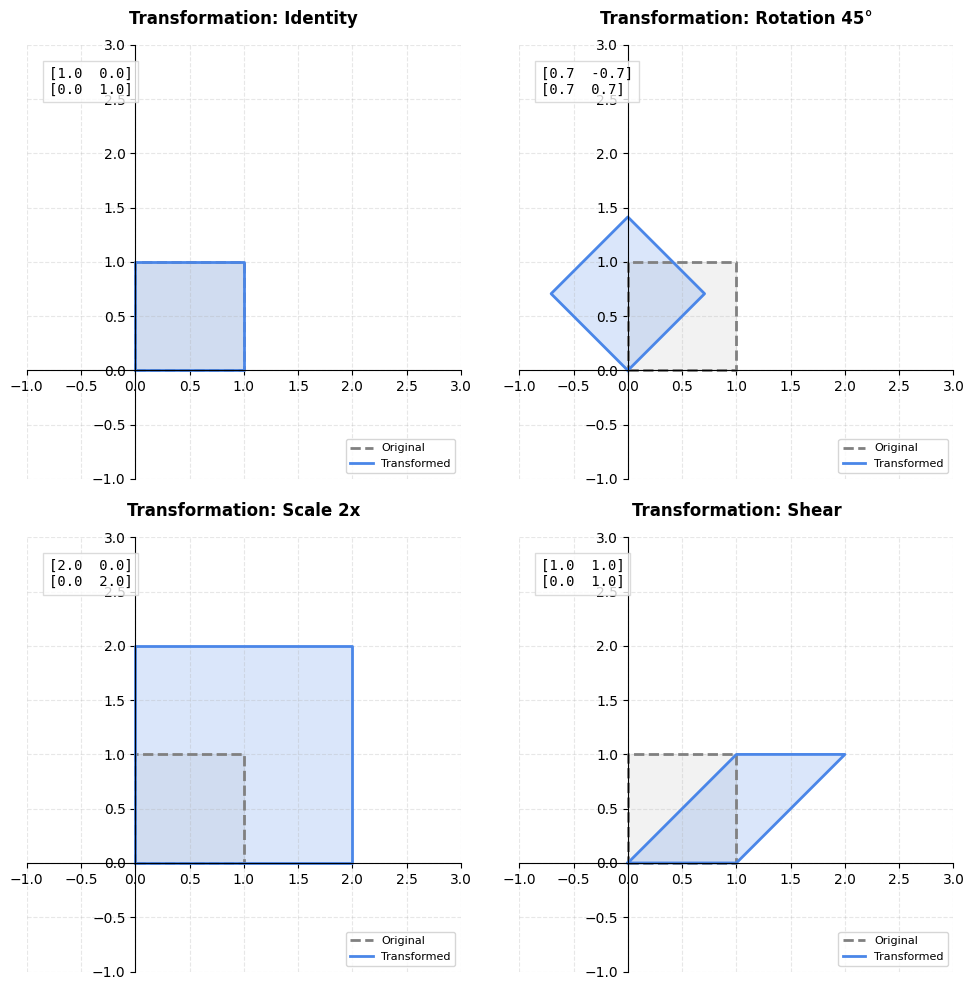

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()

matrices = {
    "Identity": np.array([[1, 0], [0, 1]]),
    "Rotation 45°": np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)], [np.sin(np.pi/4), np.cos(np.pi/4)]]),
    "Scale 2x": np.array([[2, 0], [0, 2]]),
    "Shear": np.array([[1, 1], [0, 1]])
}

square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])

for i, (title, mat) in enumerate(matrices.items()):
    ax = axs[i]
    
    transformed_square = np.dot(square, mat.T)
    
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.set_xlim(-1, 3)
    ax.set_ylim(-1, 3)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.3)
    
    ax.plot(square[:, 0], square[:, 1], linestyle='--', color='gray', label='Original', lw=2)
    ax.fill(square[:, 0], square[:, 1], color='gray', alpha=0.1)
    
    ax.plot(transformed_square[:, 0], transformed_square[:, 1], color='#4A86E8', label='Transformed', lw=2)
    ax.fill(transformed_square[:, 0], transformed_square[:, 1], color='#4A86E8', alpha=0.2)
    
    mat_str = f"[{mat[0,0]:.1f}  {mat[0,1]:.1f}]\n[{mat[1,0]:.1f}  {mat[1,1]:.1f}]"
    ax.text(0.05, 0.95, mat_str, transform=ax.transAxes, fontsize=10, fontfamily='monospace',
            va='top', bbox=dict(facecolor='white', edgecolor='lightgray', alpha=0.8))
    
    ax.set_title(f"Transformation: {title}", fontweight='bold', pad=15)
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()